# Superstore Sales Data Analysis

This notebook analyzes the Sample - Superstore dataset to uncover insights about sales, profit, and customer behavior.

In [34]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Load and Explore the Data

In [35]:
# Load the dataset
df = pd.read_csv('../01_raw_data/Sample - Superstore.csv', encoding='latin-1')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (9994, 21)

First few rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [36]:
# Data types and missing values
print("Data Info:")
df.info()
print("\nMissing Values:")
df.isnull().sum()

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [37]:
# Convert date columns to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract date features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['Day of Week'] = df['Order Date'].dt.day_name()

print("Date columns converted successfully")
df[['Order Date', 'Year', 'Month', 'Quarter']].head()

Date columns converted successfully


,Order Date,Year,Month,Quarter
0,2016-11-08,2016,11,4
1,2016-11-08,2016,11,4
2,2016-06-12,2016,6,2
3,2015-10-11,2015,10,4
4,2015-10-11,2015,10,4


## 2. Descriptive Statistics

In [38]:
# Summary statistics for numerical columns
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [39]:
# Key metrics
print("=" * 50)
print("KEY BUSINESS METRICS")
print("=" * 50)
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Average Profit Margin: {(df['Profit'].sum() / df['Sales'].sum() * 100):.2f}%")
print(f"Total Orders: {df['Order ID'].nunique():,}")
print(f"Total Customers: {df['Customer ID'].nunique():,}")
print(f"Total Products: {df['Product ID'].nunique():,}")
print(f"Average Order Value: ${df.groupby('Order ID')['Sales'].sum().mean():,.2f}")
print("=" * 50)

KEY BUSINESS METRICS
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Average Profit Margin: 12.47%
Total Orders: 5,009
Total Customers: 793
Total Products: 1,862
Average Order Value: $458.61


## 3. Sales Analysis

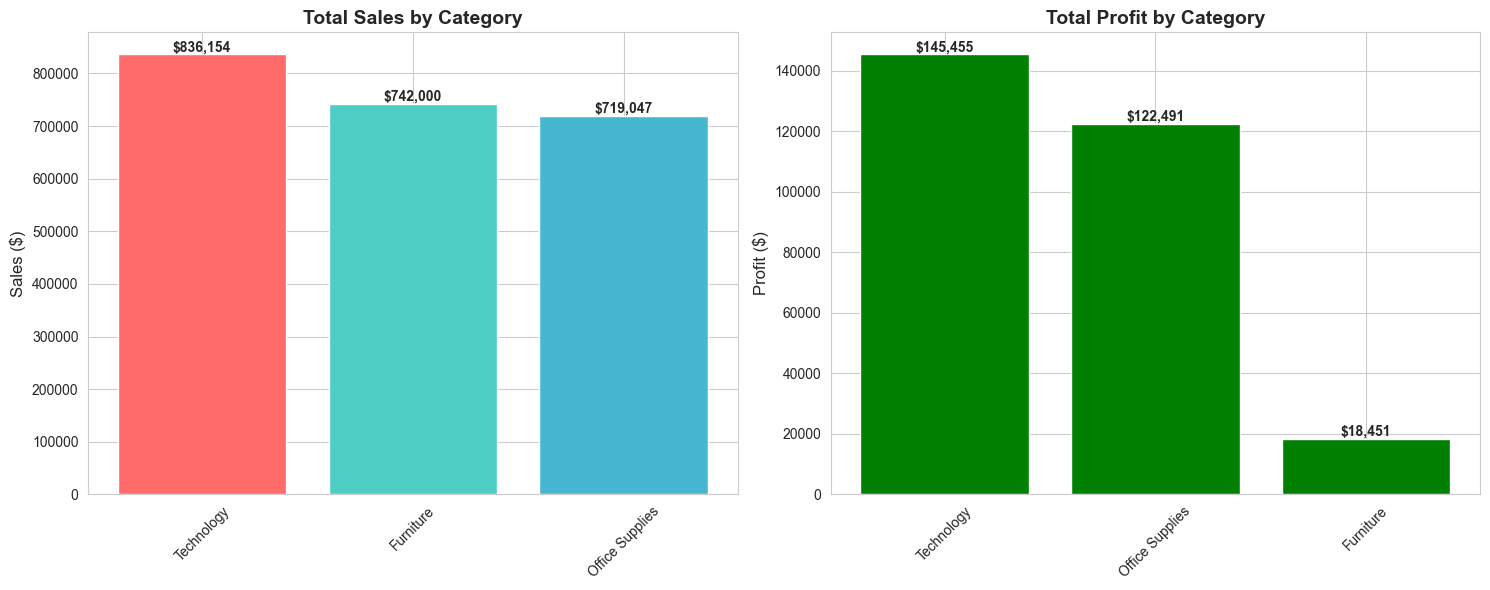

In [40]:
# Sales by Category
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
axes[0].bar(category_sales.index, category_sales.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_title('Total Sales by Category', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Sales ($)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(category_sales.values):
    axes[0].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')

# Profit by Category
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
colors = ['green' if x > 0 else 'red' for x in category_profit.values]
axes[1].bar(category_profit.index, category_profit.values, color=colors)
axes[1].set_title('Total Profit by Category', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Profit ($)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(category_profit.values):
    axes[1].text(i, v, f'${v:,.0f}', ha='center', va='bottom' if v > 0 else 'top', fontweight='bold')

plt.tight_layout()
plt.show()

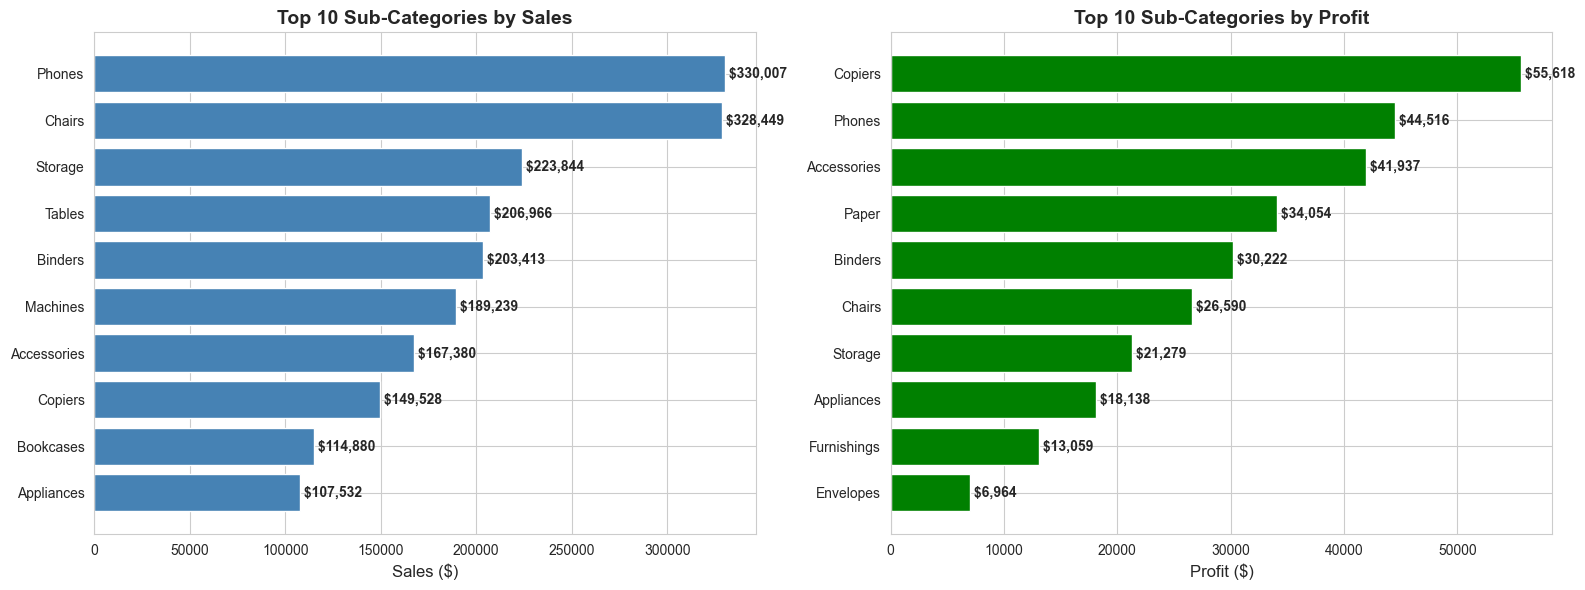

In [41]:
# Sales by Sub-Category (Top 10)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
axes[0].barh(subcategory_sales.index, subcategory_sales.values, color='steelblue')
axes[0].set_title('Top 10 Sub-Categories by Sales', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sales ($)', fontsize=12)
axes[0].invert_yaxis()
for i, v in enumerate(subcategory_sales.values):
    axes[0].text(v, i, f' ${v:,.0f}', va='center', fontweight='bold')

subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)
colors = ['green' if x > 0 else 'red' for x in subcategory_profit.values]
axes[1].barh(subcategory_profit.index, subcategory_profit.values, color=colors)
axes[1].set_title('Top 10 Sub-Categories by Profit', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Profit ($)', fontsize=12)
axes[1].invert_yaxis()
for i, v in enumerate(subcategory_profit.values):
    axes[1].text(v, i, f' ${v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Time Series Analysis

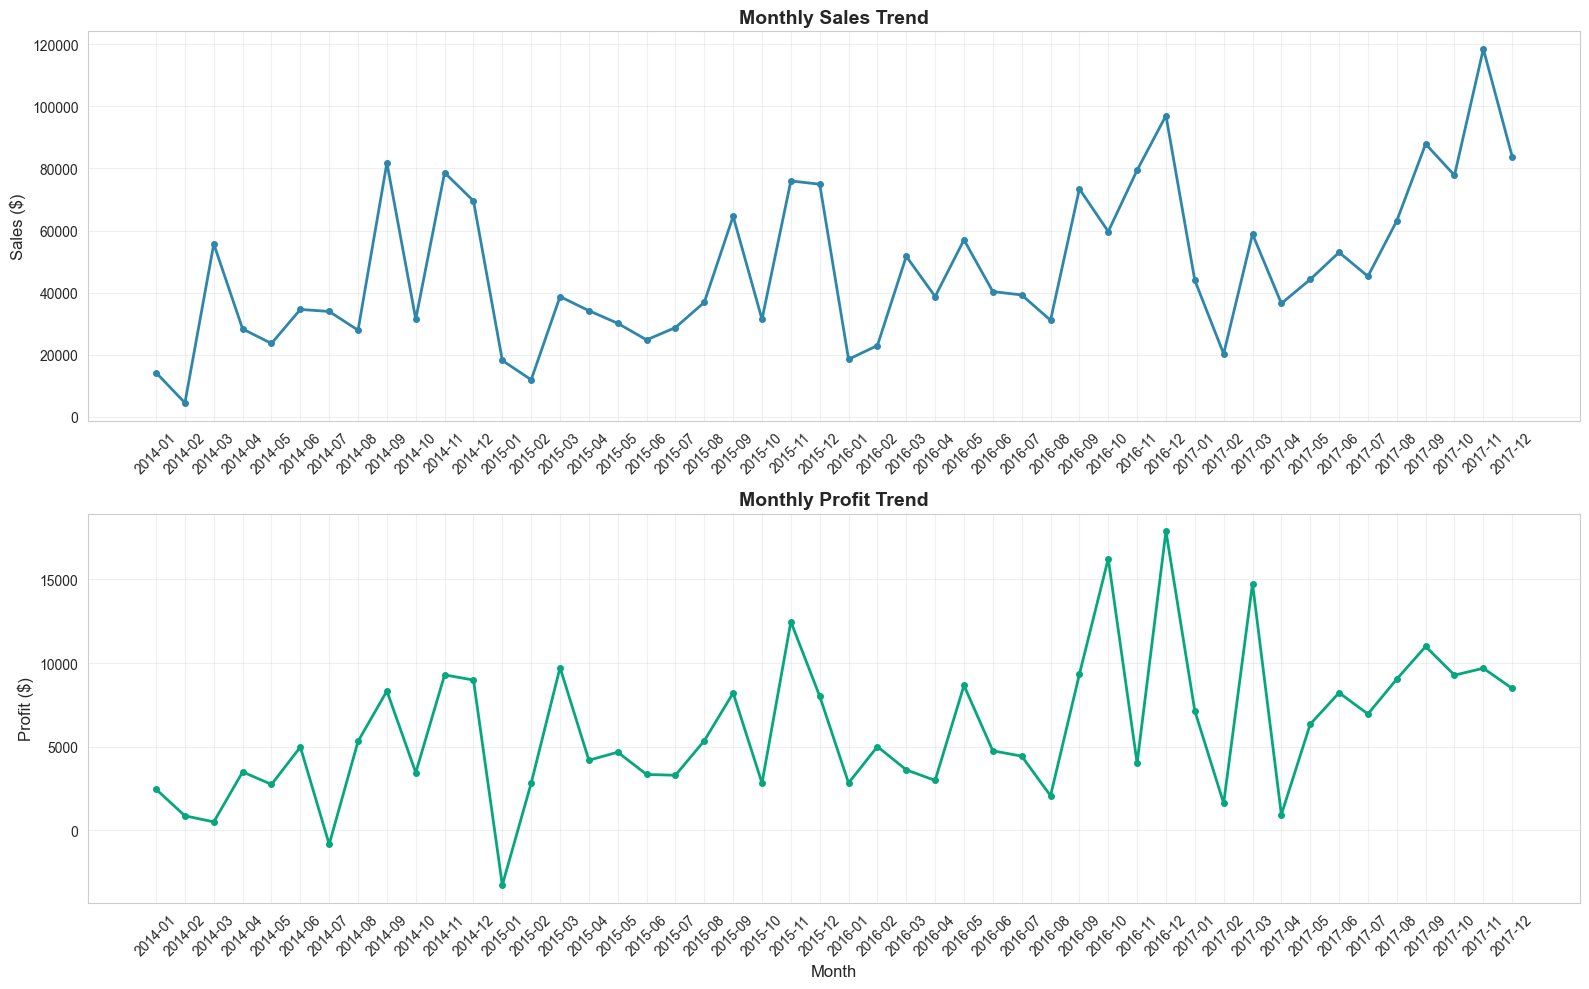

In [42]:
# Monthly sales trend
monthly_sales = df.groupby([df['Order Date'].dt.to_period('M')])['Sales'].sum()
monthly_profit = df.groupby([df['Order Date'].dt.to_period('M')])['Profit'].sum()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Sales trend
axes[0].plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', linewidth=2, markersize=4, color='#2E86AB')
axes[0].set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Sales ($)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Profit trend
axes[1].plot(monthly_profit.index.astype(str), monthly_profit.values, marker='o', linewidth=2, markersize=4, color='#06A77D')
axes[1].set_title('Monthly Profit Trend', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Profit ($)', fontsize=12)
axes[1].set_xlabel('Month', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [43]:
# Yearly comparison
yearly_data = df.groupby('Year').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).round(2)

yearly_data.columns = ['Total Sales', 'Total Profit', 'Number of Orders']
yearly_data['Profit Margin %'] = (yearly_data['Total Profit'] / yearly_data['Total Sales'] * 100).round(2)

print("\nYearly Performance:")
yearly_data


Yearly Performance:


,Total Sales,Total Profit,Number of Orders,Profit Margin %
Year,,,,
2014,484247.50,49543.97,969,10.23
2015,470532.51,61618.60,1038,13.10
2016,609205.60,81795.17,1315,13.43
2017,733215.26,93439.27,1687,12.74


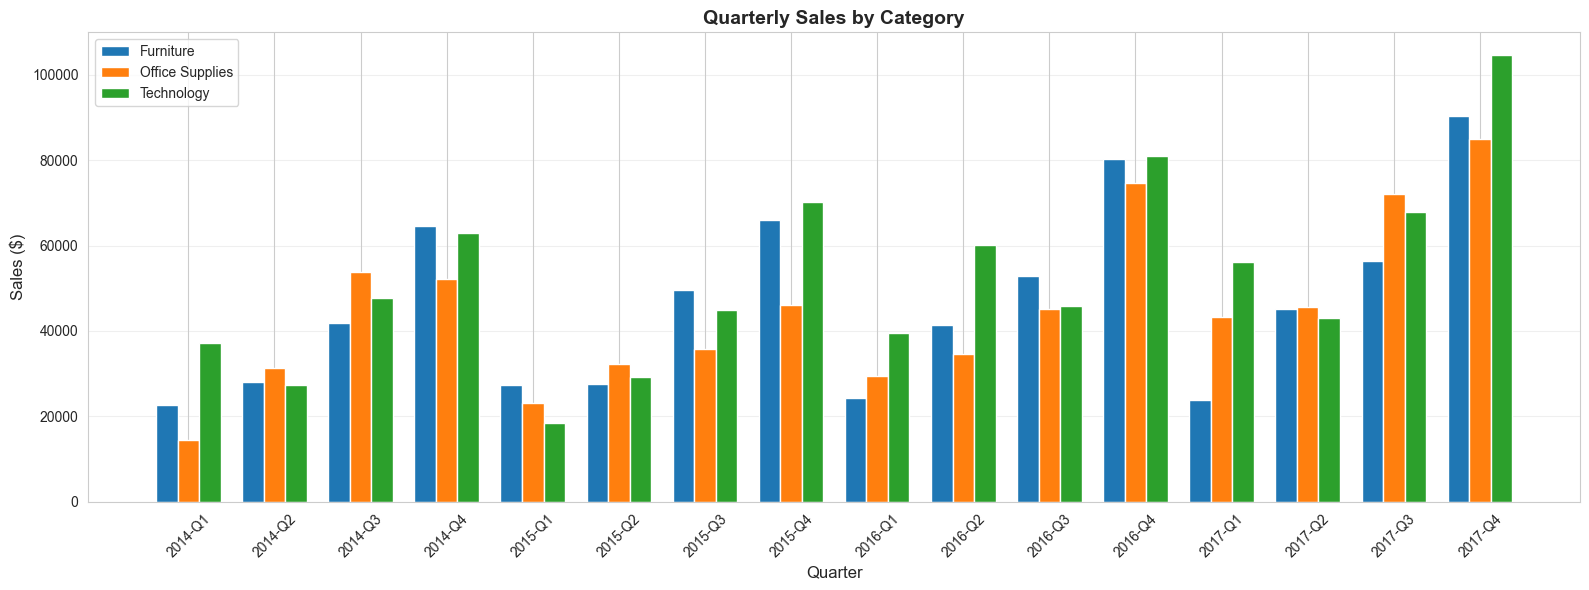

In [44]:
# Quarterly sales by category
quarterly_category = df.groupby(['Year', 'Quarter', 'Category'])['Sales'].sum().reset_index()
quarterly_category['Period'] = quarterly_category['Year'].astype(str) + '-Q' + quarterly_category['Quarter'].astype(str)

fig, ax = plt.subplots(figsize=(16, 6))
categories = quarterly_category['Category'].unique()
x = np.arange(len(quarterly_category['Period'].unique()))
width = 0.25

for i, category in enumerate(categories):
    data = quarterly_category[quarterly_category['Category'] == category]
    ax.bar(x + i * width, data['Sales'].values, width, label=category)

ax.set_xlabel('Quarter', fontsize=12)
ax.set_ylabel('Sales ($)', fontsize=12)
ax.set_title('Quarterly Sales by Category', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(quarterly_category['Period'].unique(), rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Regional Analysis

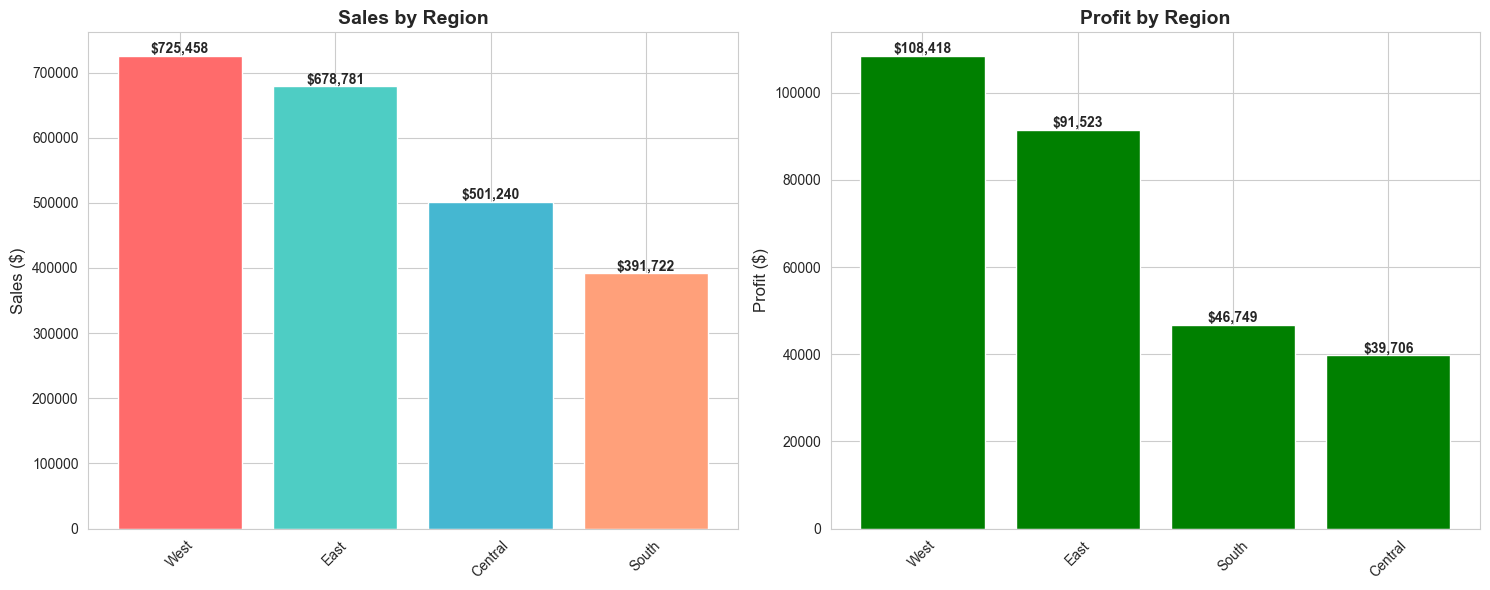

In [45]:
# Sales and Profit by Region
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[0].bar(region_sales.index, region_sales.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[0].set_title('Sales by Region', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Sales ($)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(region_sales.values):
    axes[0].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')

region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
colors = ['green' if x > 0 else 'red' for x in region_profit.values]
axes[1].bar(region_profit.index, region_profit.values, color=colors)
axes[1].set_title('Profit by Region', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Profit ($)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(region_profit.values):
    axes[1].text(i, v, f'${v:,.0f}', ha='center', va='bottom' if v > 0 else 'top', fontweight='bold')

plt.tight_layout()
plt.show()

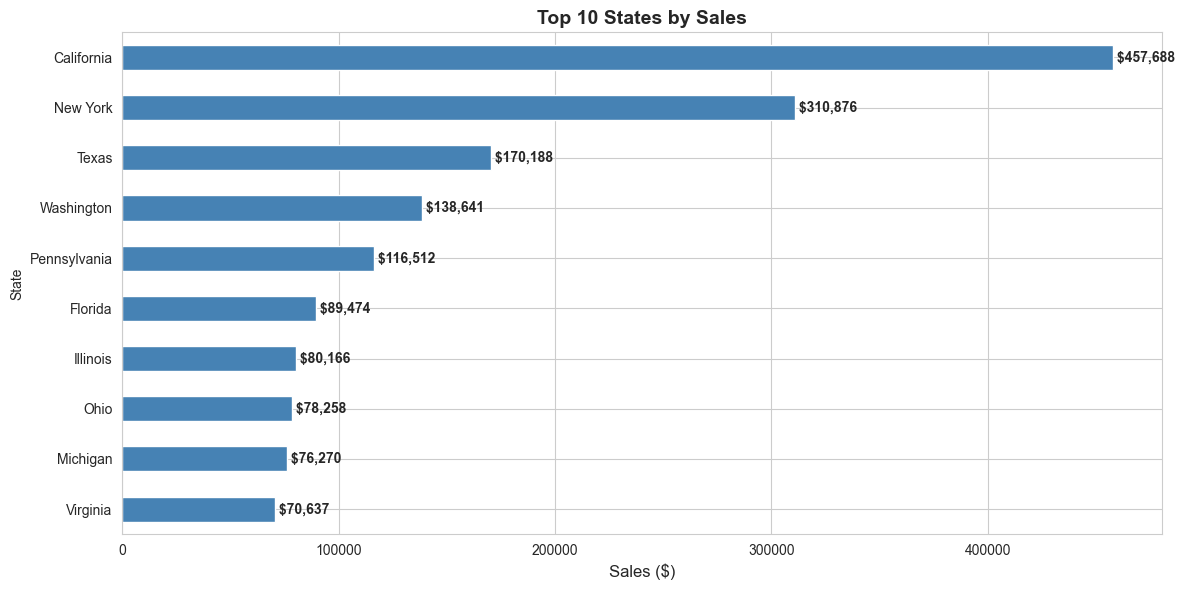


Top 10 States Performance:


,Sales,Profit,Order ID
State,,,
California,457687.6315,76381.3871,1021
New York,310876.2710,74038.5486,562
Texas,170188.0458,-25729.3563,487
Washington,138641.2700,33402.6517,256
Pennsylvania,116511.9140,-15559.9603,288
Florida,89473.7080,-3399.3017,200
Illinois,80166.1010,-12607.8870,276
Ohio,78258.1360,-16971.3766,236
Michigan,76269.6140,24463.1876,117


In [46]:
# Top 10 states by sales
state_performance = df.groupby('State').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).sort_values('Sales', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
state_performance['Sales'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 States by Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Sales ($)', fontsize=12)
ax.invert_yaxis()
for i, v in enumerate(state_performance['Sales'].values):
    ax.text(v, i, f' ${v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTop 10 States Performance:")
state_performance

## 6. Customer Segment Analysis

In [47]:
# Sales and Profit by Segment
segment_analysis = df.groupby('Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique',
    'Customer ID': 'nunique'
}).round(2)

segment_analysis.columns = ['Total Sales', 'Total Profit', 'Orders', 'Customers']
segment_analysis['Avg Order Value'] = (segment_analysis['Total Sales'] / segment_analysis['Orders']).round(2)
segment_analysis['Profit Margin %'] = (segment_analysis['Total Profit'] / segment_analysis['Total Sales'] * 100).round(2)

print("Segment Performance:")
segment_analysis

Segment Performance:


,Total Sales,Total Profit,Orders,Customers,Avg Order Value,Profit Margin %
Segment,,,,,,
Consumer,1161401.34,134119.21,2586,409,449.11,11.55
Corporate,706146.37,91979.13,1514,236,466.41,13.03
Home Office,429653.15,60298.68,909,148,472.67,14.03


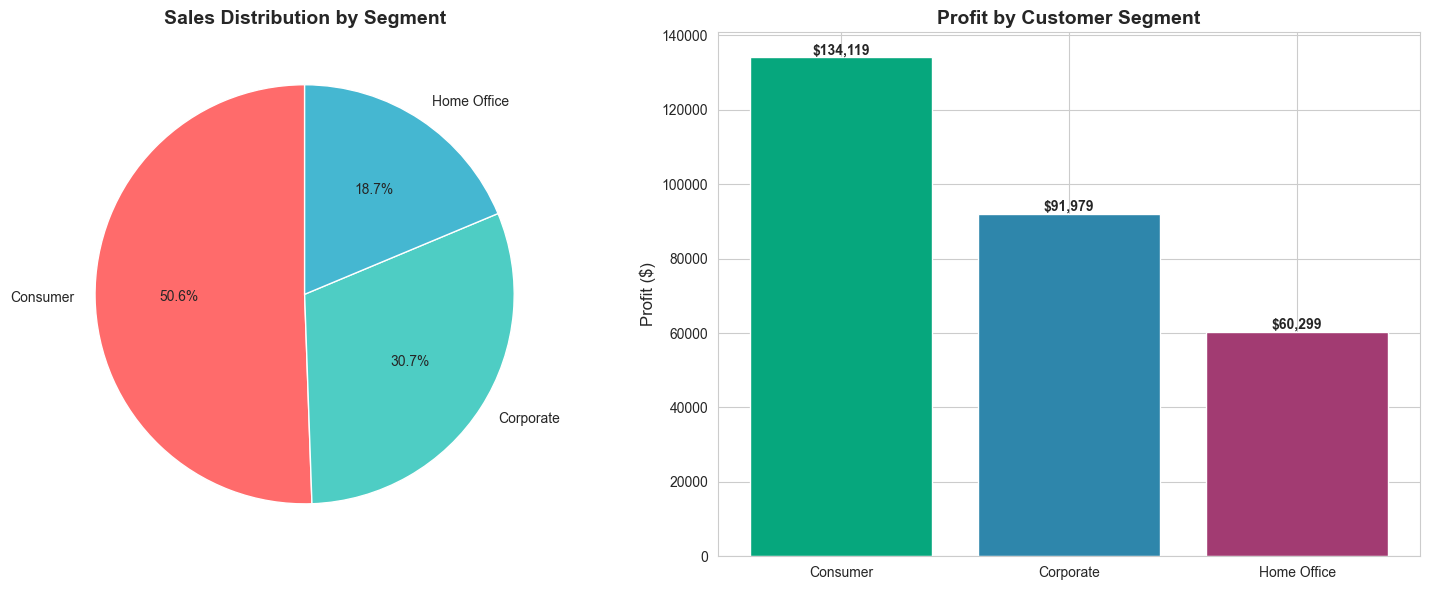

In [48]:
# Visualize segment distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart for sales distribution
segment_sales = df.groupby('Segment')['Sales'].sum()
axes[0].pie(segment_sales.values, labels=segment_sales.index, autopct='%1.1f%%', startangle=90, colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_title('Sales Distribution by Segment', fontsize=14, fontweight='bold')

# Bar chart for profit by segment
segment_profit = df.groupby('Segment')['Profit'].sum()
axes[1].bar(segment_profit.index, segment_profit.values, color=['#06A77D', '#2E86AB', '#A23B72'])
axes[1].set_title('Profit by Customer Segment', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Profit ($)', fontsize=12)
for i, v in enumerate(segment_profit.values):
    axes[1].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Product Analysis

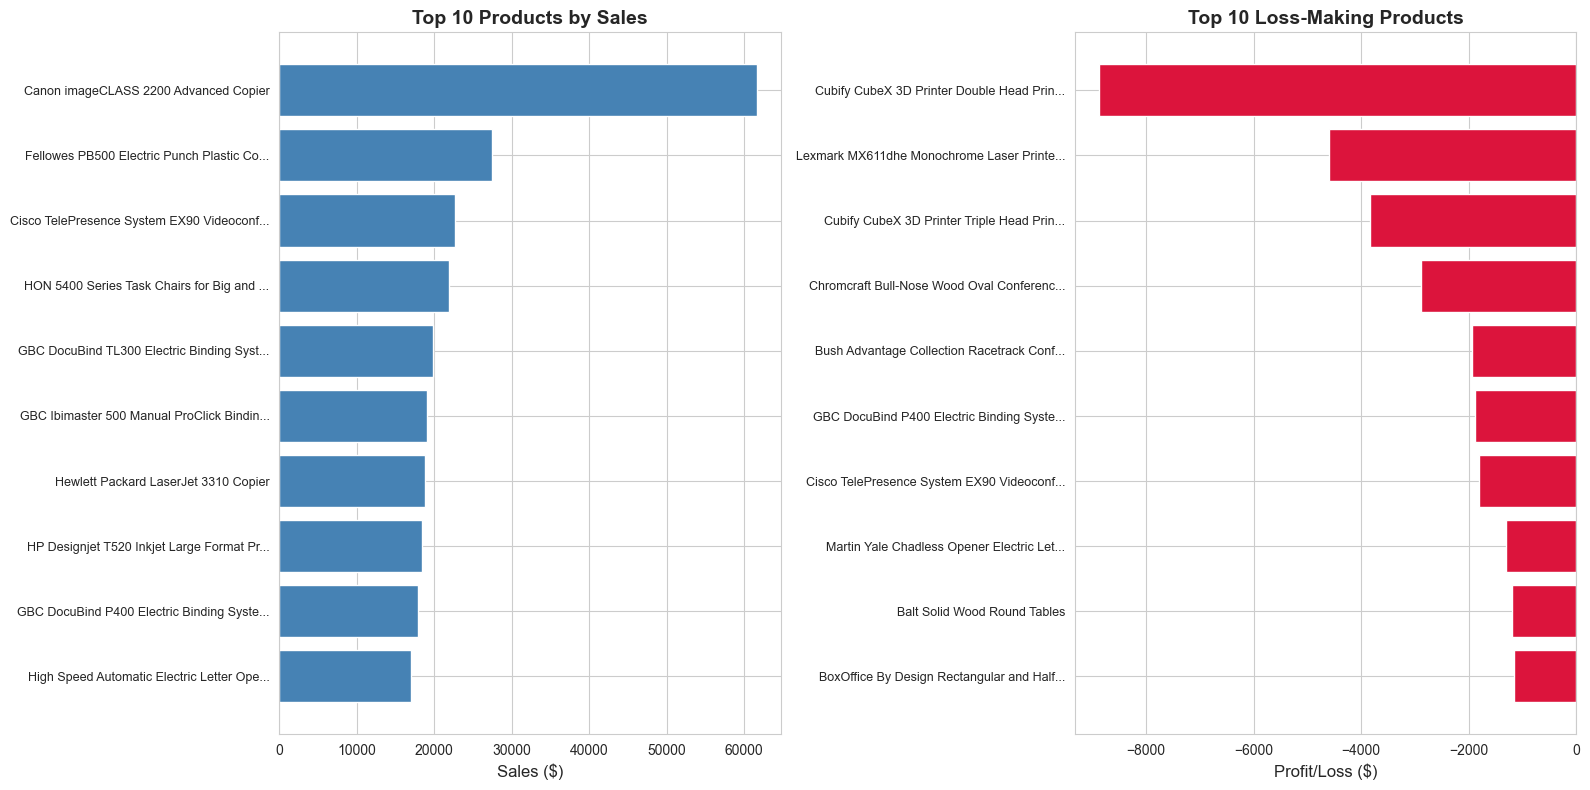

In [49]:
# Top 10 products by sales and profit
top_products_sales = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
worst_products_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top products by sales
axes[0].barh(range(len(top_products_sales)), top_products_sales.values, color='steelblue')
axes[0].set_yticks(range(len(top_products_sales)))
axes[0].set_yticklabels([label[:40] + '...' if len(label) > 40 else label for label in top_products_sales.index], fontsize=9)
axes[0].set_title('Top 10 Products by Sales', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sales ($)', fontsize=12)
axes[0].invert_yaxis()

# Worst products by profit (most loss-making)
axes[1].barh(range(len(worst_products_profit)), worst_products_profit.values, color='crimson')
axes[1].set_yticks(range(len(worst_products_profit)))
axes[1].set_yticklabels([label[:40] + '...' if len(label) > 40 else label for label in worst_products_profit.index], fontsize=9)
axes[1].set_title('Top 10 Loss-Making Products', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Profit/Loss ($)', fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Shipping Mode Analysis

In [50]:
# Analysis by shipping mode
ship_mode_analysis = df.groupby('Ship Mode').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).sort_values('Sales', ascending=False)

ship_mode_analysis.columns = ['Total Sales', 'Total Profit', 'Number of Orders']
ship_mode_analysis['Avg Order Value'] = (ship_mode_analysis['Total Sales'] / ship_mode_analysis['Number of Orders']).round(2)

print("Shipping Mode Performance:")
ship_mode_analysis

Shipping Mode Performance:


,Total Sales,Total Profit,Number of Orders,Avg Order Value
Ship Mode,,,,
Standard Class,1.358216e+06,164088.7875,2994,453.65
Second Class,4.591936e+05,57446.6354,964,476.34
First Class,3.514284e+05,48969.8399,787,446.54
Same Day,1.283631e+05,15891.7589,264,486.22


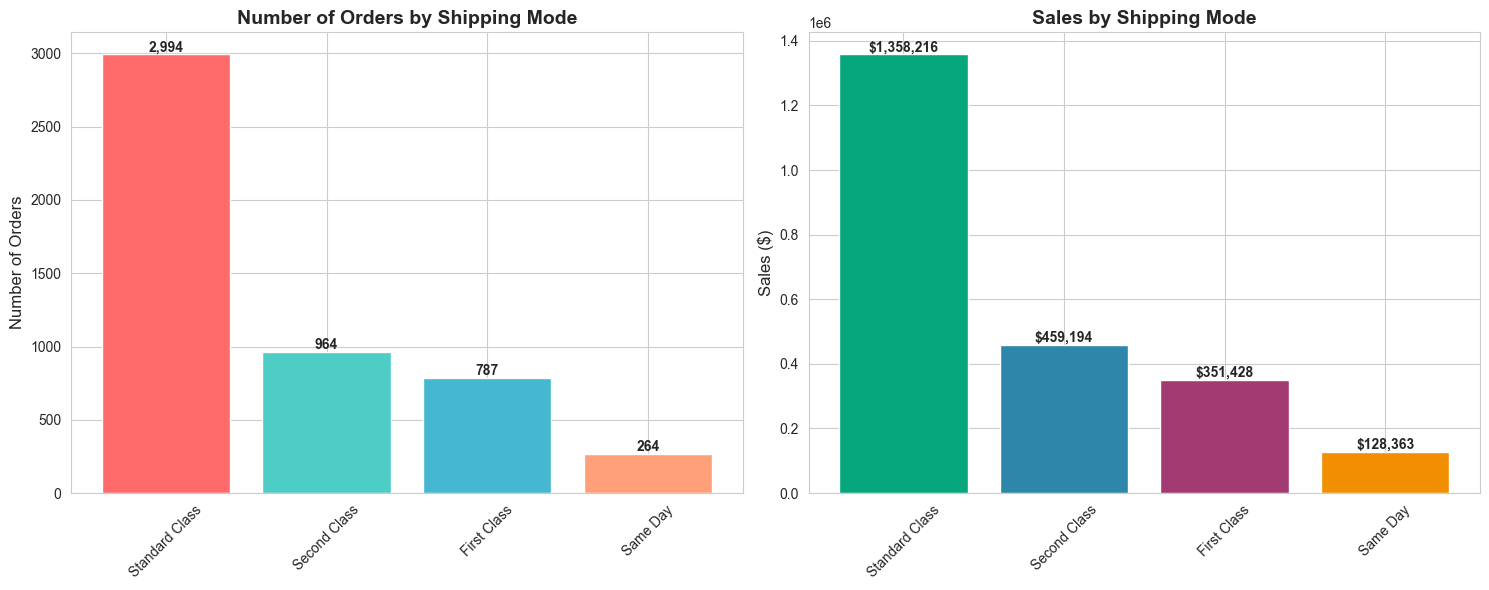

In [51]:
# Visualize shipping mode distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ship_mode_orders = df.groupby('Ship Mode')['Order ID'].nunique().sort_values(ascending=False)
axes[0].bar(ship_mode_orders.index, ship_mode_orders.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[0].set_title('Number of Orders by Shipping Mode', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Orders', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(ship_mode_orders.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

ship_mode_sales = df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)
axes[1].bar(ship_mode_sales.index, ship_mode_sales.values, color=['#06A77D', '#2E86AB', '#A23B72', '#F18F01'])
axes[1].set_title('Sales by Shipping Mode', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Sales ($)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(ship_mode_sales.values):
    axes[1].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Discount Analysis

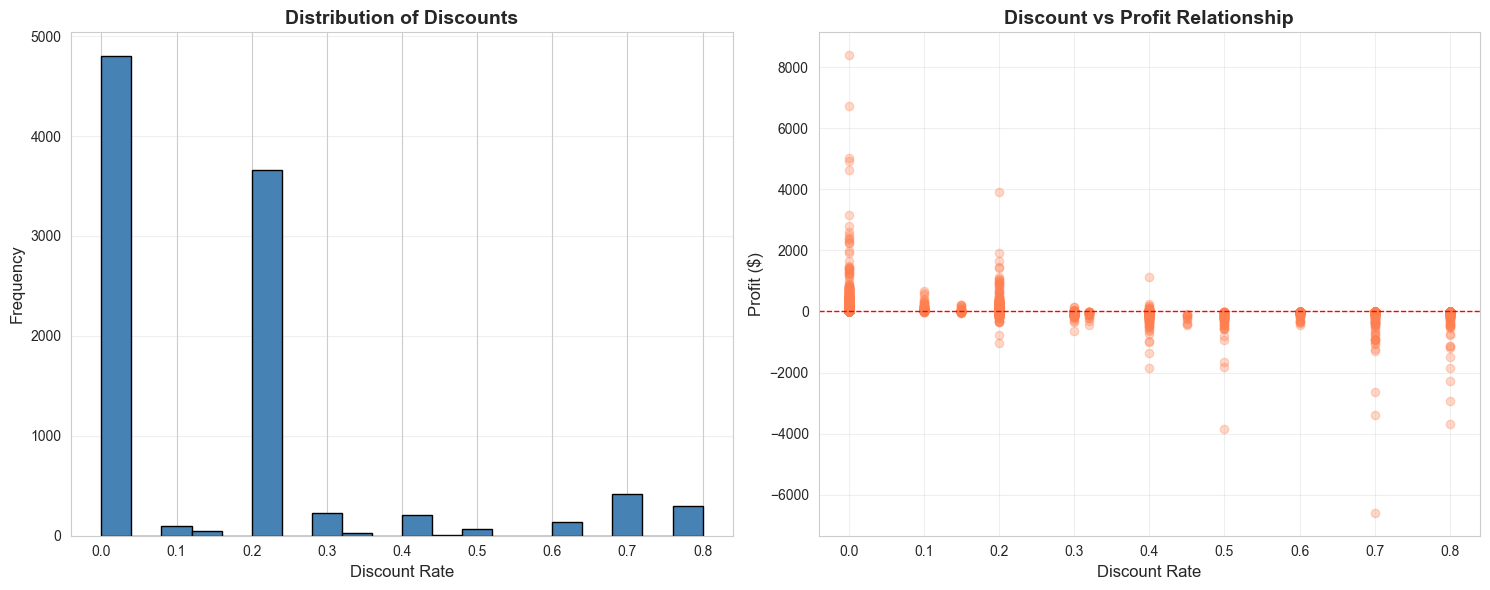

In [52]:
# Discount distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram of discount distribution
axes[0].hist(df['Discount'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Discounts', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Discount Rate', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# Scatter plot: Discount vs Profit
axes[1].scatter(df['Discount'], df['Profit'], alpha=0.3, color='coral')
axes[1].set_title('Discount vs Profit Relationship', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Discount Rate', fontsize=12)
axes[1].set_ylabel('Profit ($)', fontsize=12)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
# Create discount bins for analysis
df['Discount Bin'] = pd.cut(df['Discount'], bins=[0, 0.1, 0.2, 0.3, 1.0], labels=['0-10%', '10-20%', '20-30%', '30%+'])

discount_analysis = df.groupby('Discount Bin').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'count'
}).round(2)

discount_analysis.columns = ['Total Sales', 'Total Profit', 'Transaction Count']
discount_analysis['Avg Profit per Transaction'] = (discount_analysis['Total Profit'] / discount_analysis['Transaction Count']).round(2)

print("\nDiscount Impact Analysis:")
discount_analysis


Discount Impact Analysis:


,Total Sales,Total Profit,Transaction Count,Avg Profit per Transaction
Discount Bin,,,,
0-10%,54369.35,9029.18,94,96.06
10-20%,792152.89,91756.30,3709,24.74
20-30%,103226.66,-10369.28,227,-45.68
30%+,259543.49,-125006.78,1166,-107.21


## 10. Correlation Analysis

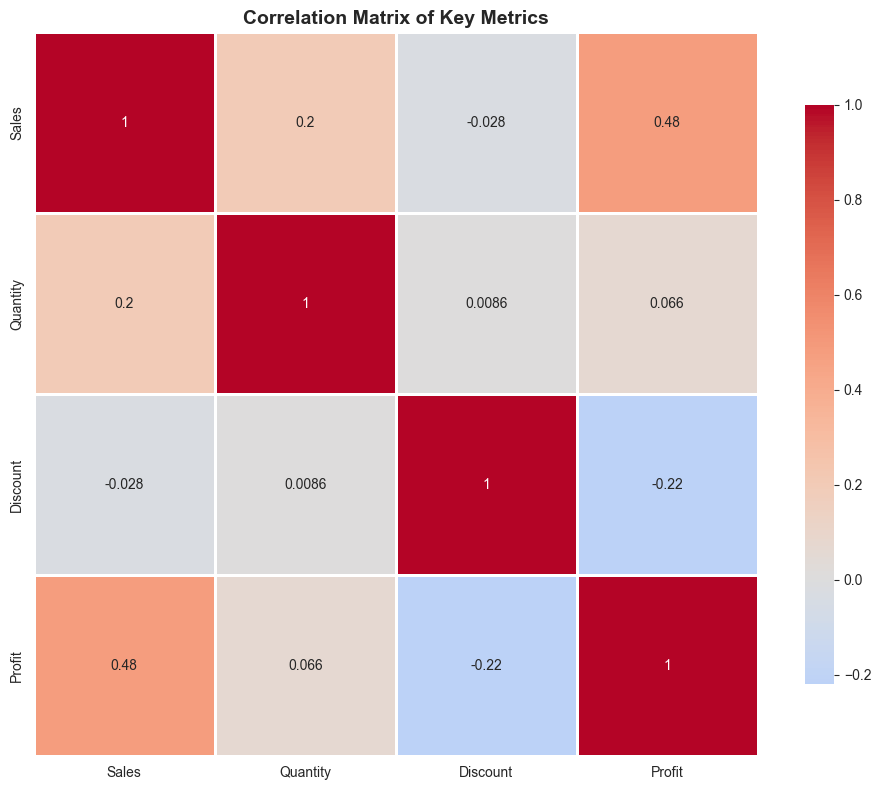

In [54]:
# Correlation heatmap
correlation_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
correlation_matrix = df[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Key Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Key Insights Summary

In [55]:
print("=" * 70)
print("KEY INSIGHTS FROM SUPERSTORE DATA ANALYSIS")
print("=" * 70)

# Overall performance
print("\n1. OVERALL PERFORMANCE:")
print(f"   - Total Revenue: ${df['Sales'].sum():,.2f}")
print(f"   - Total Profit: ${df['Profit'].sum():,.2f}")
print(f"   - Profit Margin: {(df['Profit'].sum() / df['Sales'].sum() * 100):.2f}%")

# Category insights
print("\n2. CATEGORY PERFORMANCE:")
category_stats = df.groupby('Category').agg({'Sales': 'sum', 'Profit': 'sum'})
best_category = category_stats['Sales'].idxmax()
print(f"   - Highest Sales Category: {best_category} (${category_stats.loc[best_category, 'Sales']:,.2f})")
best_profit_category = category_stats['Profit'].idxmax()
print(f"   - Most Profitable Category: {best_profit_category} (${category_stats.loc[best_profit_category, 'Profit']:,.2f})")

# Regional insights
print("\n3. REGIONAL PERFORMANCE:")
region_stats = df.groupby('Region').agg({'Sales': 'sum', 'Profit': 'sum'})
best_region = region_stats['Sales'].idxmax()
print(f"   - Top Performing Region: {best_region} (${region_stats.loc[best_region, 'Sales']:,.2f})")
print(f"   - Region Profit: ${region_stats.loc[best_region, 'Profit']:,.2f}")

# Customer segment insights
print("\n4. CUSTOMER SEGMENT:")
segment_stats = df.groupby('Segment').agg({'Sales': 'sum', 'Customer ID': 'nunique'})
top_segment = segment_stats['Sales'].idxmax()
print(f"   - Largest Segment by Sales: {top_segment} (${segment_stats.loc[top_segment, 'Sales']:,.2f})")
print(f"   - Unique Customers in {top_segment}: {segment_stats.loc[top_segment, 'Customer ID']:,}")

# Discount insights
print("\n5. DISCOUNT IMPACT:")
avg_profit_no_discount = df[df['Discount'] == 0]['Profit'].mean()
avg_profit_with_discount = df[df['Discount'] > 0]['Profit'].mean()
print(f"   - Average Profit (No Discount): ${avg_profit_no_discount:.2f}")
print(f"   - Average Profit (With Discount): ${avg_profit_with_discount:.2f}")
print(f"   - Impact: {((avg_profit_with_discount - avg_profit_no_discount) / avg_profit_no_discount * 100):.2f}%")

# Temporal insights
print("\n6. TEMPORAL TRENDS:")
best_year = df.groupby('Year')['Sales'].sum().idxmax()
best_year_sales = df.groupby('Year')['Sales'].sum().max()
print(f"   - Best Performing Year: {best_year} (${best_year_sales:,.2f})")

print("\n" + "=" * 70)

KEY INSIGHTS FROM SUPERSTORE DATA ANALYSIS

1. OVERALL PERFORMANCE:
   - Total Revenue: $2,297,200.86
   - Total Profit: $286,397.02
   - Profit Margin: 12.47%

2. CATEGORY PERFORMANCE:
   - Highest Sales Category: Technology ($836,154.03)
   - Most Profitable Category: Technology ($145,454.95)

3. REGIONAL PERFORMANCE:
   - Top Performing Region: West ($725,457.82)
   - Region Profit: $108,418.45

4. CUSTOMER SEGMENT:
   - Largest Segment by Sales: Consumer ($1,161,401.34)
   - Unique Customers in Consumer: 409

5. DISCOUNT IMPACT:
   - Average Profit (No Discount): $66.90
   - Average Profit (With Discount): $-6.66
   - Impact: -109.95%

6. TEMPORAL TRENDS:
   - Best Performing Year: 2017 ($733,215.26)

